<a href="https://colab.research.google.com/github/prashanth21156/Iris-ML-Project-2/blob/main/Iris_ML_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 02 — Iris Flower Classification: Machine Learning Model
**Pluto Academy AI & ML Internship**

Dataset: [Iris Flower Dataset](https://www.kaggle.com/datasets/uciml/iris)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Step 1 — Load, Explore & Preprocess

In [4]:
df = pd.read_csv("Iris.csv")

print("Shape:", df.shape)
df.head()


Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df["Species"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class balance:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [6]:
# Drop the Id column if present — it's just a row index, not a real feature
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

df.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Preprocessing decisions:**
- Missing values: Iris is a very clean dataset, so typically none to handle — confirm this from the output above.
- Categorical encoding: `Species` (the target) needs to be label-encoded for some workflows, though scikit-learn classifiers can also work with string labels directly. We'll encode it below for consistency with metrics.
- Dropped `Id` — it's an arbitrary row index with no predictive value.


In [7]:
le = LabelEncoder()
df["Species_encoded"] = le.fit_transform(df["Species"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=["Species", "Species_encoded"])
y = df["Species_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Train shape: (120, 4) Test shape: (30, 4)


## Step 2 — Feature Engineering

Species_encoded    1.000000
PetalWidthCm       0.956464
PetalLengthCm      0.949043
SepalLengthCm      0.782561
SepalWidthCm      -0.419446
Name: Species_encoded, dtype: float64


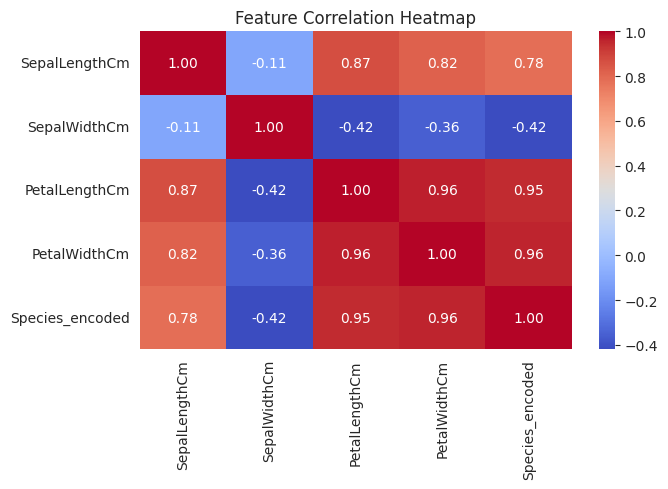

In [8]:
# Correlation of each feature with the target
corr_with_target = df.drop(columns=["Species"]).corr()["Species_encoded"].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns=["Species"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


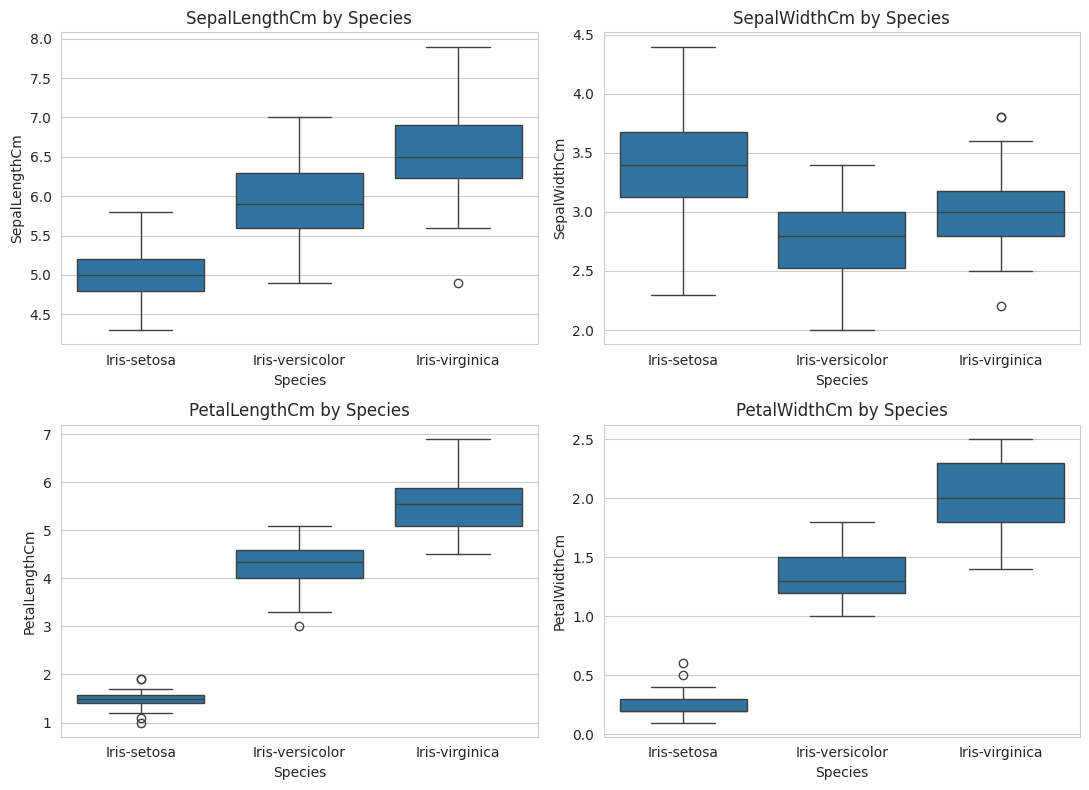

In [9]:
# Visualize how well each feature separates the species — helps justify feature importance
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = [c for c in X.columns]
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feat, ax=ax)
    ax.set_title(f"{feat} by Species")
plt.tight_layout()
plt.show()


PetalWidthCm     0.437185
PetalLengthCm    0.431466
SepalLengthCm    0.116349
SepalWidthCm     0.015000
dtype: float64


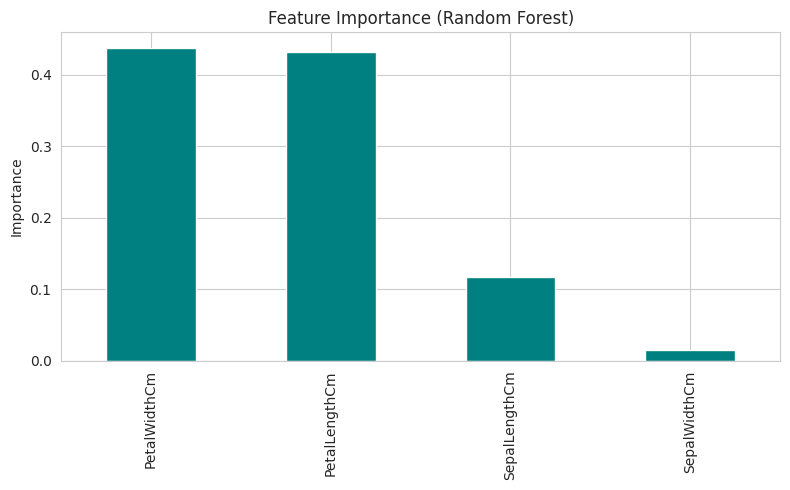

In [10]:
# Feature importance from a quick Random Forest fit (used for justification, not the final model yet)
rf_check = RandomForestClassifier(random_state=42)
rf_check.fit(X_train, y_train)
importances = pd.Series(rf_check.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind="bar", color="teal")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


**Feature engineering notes:**
Iris only has 4 features, all biologically meaningful (petal/sepal length & width), so none are irrelevant enough to drop. Note here which 1–2 features the correlation and importance plots show as most predictive (typically petal length/width) — this justifies why we keep all four rather than dropping any.


## Step 3 — Train 3 Different Models

In [11]:
# Scale features for models sensitive to feature scale (Logistic Regression, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

predictions = {}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    predictions[name] = preds
    print(f"{name} trained.")


Logistic Regression trained.
Random Forest trained.
KNN trained.
